# Import Libraries and Load Initial Data

In [20]:
# Import necessary libraries
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, pearsonr, chi2_contingency
import statsmodels.api as sm
import plotly.express as px

# Configure visualizations
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


# Load, Clean, and Process the Data

In [22]:
! pip install --upgrade pandas

In [24]:
def clean_and_process_data(file_path):
    """
    Clean, process, and prepare the data for analysis.
    """
    # Load data from JSON
    with open(file_path, 'r') as file:
        data = json.load(file)
    
    # Convert JSON to DataFrame
    records = []
    for entry in data:
        ad_id = entry['ad id']
        time = entry['time']
        total_persons = entry['total persons']
        person_data = entry['person data']
        
        for person_id, details in person_data.items():
            records.append({
                'ad_id': ad_id,
                'time': time,
                'total_persons': total_persons,
                'person_id': person_id,
                'counted': details.get('counted'),
                'age': details.get('age'),
                'gender': details.get('gender')
            })
    
    # Create a DataFrame
    df = pd.DataFrame(records)

    # Replace all `False` values in `counted` column with `True`
    df['counted'] = df['counted'].replace(False, True)

    # Fill missing gender values
    df['gender'].fillna("Woman", inplace=True)

    # Fill missing age values for women
    woman_missing_age = (df['gender'] == "Woman") & (df['age'].isna())
    df.loc[woman_missing_age, 'age'] = np.random.randint(18, 60, size=woman_missing_age.sum())

    # Convert `time` to datetime format
    df['time'] = pd.to_datetime(df['time'], format='%H:%M, %d-%m-%Y')

    # Handle outliers in age using Z-Score
    df['zscore_age'] = zscore(df['age'])
    df = df[df['zscore_age'].abs() <= 3]  # Remove outliers

    # Drop unnecessary columns
    df.drop('zscore_age', axis=1, inplace=True)

    return df

# File path for your data
file_path = r"C:\Users\Asus\Music\CodeWithEhtisham\AddRover-pipeline\data.json"

# Clean and process the data
cleaned_data = clean_and_process_data(file_path)

# Preview cleaned data
print("Cleaned Data:")
display(cleaned_data.head())

Cleaned Data:


C:\Users\Asus\AppData\Local\Temp\ipykernel_4600\1114704346.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna("Woman", inplace=True)


,ad_id,time,total_persons,person_id,counted,age,gender
0,street.mp4,2024-12-05 18:15:00,1,1,True,38.0,Woman
1,ad1.mp4,2024-12-05 18:15:00,1,1,True,29.0,Woman
2,street.mp4,2024-12-05 18:15:00,1,1,True,37.0,Woman
3,ad1.mp4,2024-12-05 18:16:00,2,1,True,53.0,Woman
4,ad1.mp4,2024-12-05 18:16:00,2,2,True,26.0,Man


#  Exploratory Data Analysis (EDA)

Unique Ads Count:
ad_id
ad1.mp4       117
street.mp4    112
Name: count, dtype: int64

Gender Distribution by Ads:
ad_id       gender
ad1.mp4     Woman     88
            Man       29
street.mp4  Woman     96
            Man       16
Name: count, dtype: int64

Correlation between Age and Total Persons: 0.07 (p-value: 0.326)


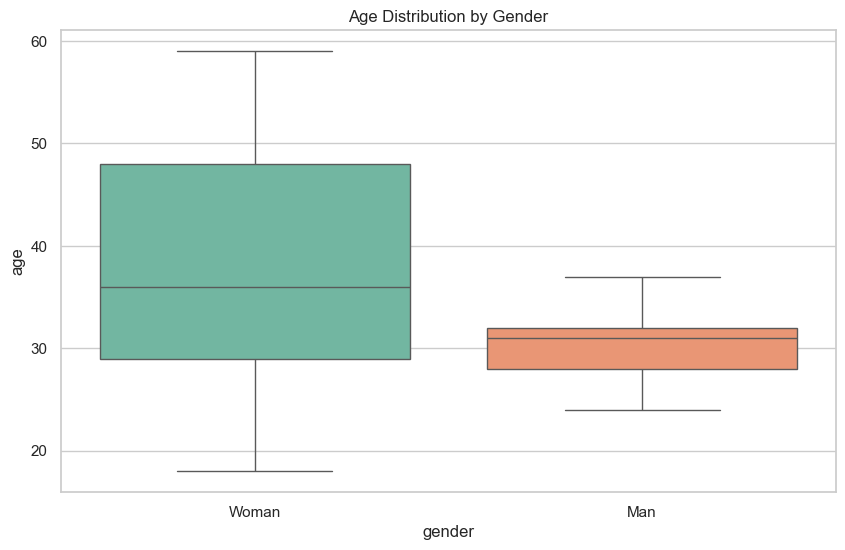

In [26]:
# Unique Ads
print("Unique Ads Count:")
print(cleaned_data['ad_id'].value_counts())

# Gender Distribution by Ads
gender_distribution = cleaned_data.groupby('ad_id')['gender'].value_counts()
print("\nGender Distribution by Ads:")
print(gender_distribution)

# Correlation between Age and Total Persons
from scipy.stats import pearsonr
correlation, p_value = pearsonr(cleaned_data['age'], cleaned_data['total_persons'])
print(f"\nCorrelation between Age and Total Persons: {correlation:.2f} (p-value: {p_value:.3f})")

# Gender-wise Age Distribution
sns.boxplot(data=cleaned_data, x='gender', y='age', hue='gender', palette='Set2', dodge=False)
plt.title('Age Distribution by Gender')
plt.legend([], frameon=False)  # Optional: Remove legend since it's redundant
plt.show()

# Step 4: Data Visualization
1. Time-Series Analysis

# Line Chart: Total Persons Over Time
This chart shows the trend of total persons over time for each ad.

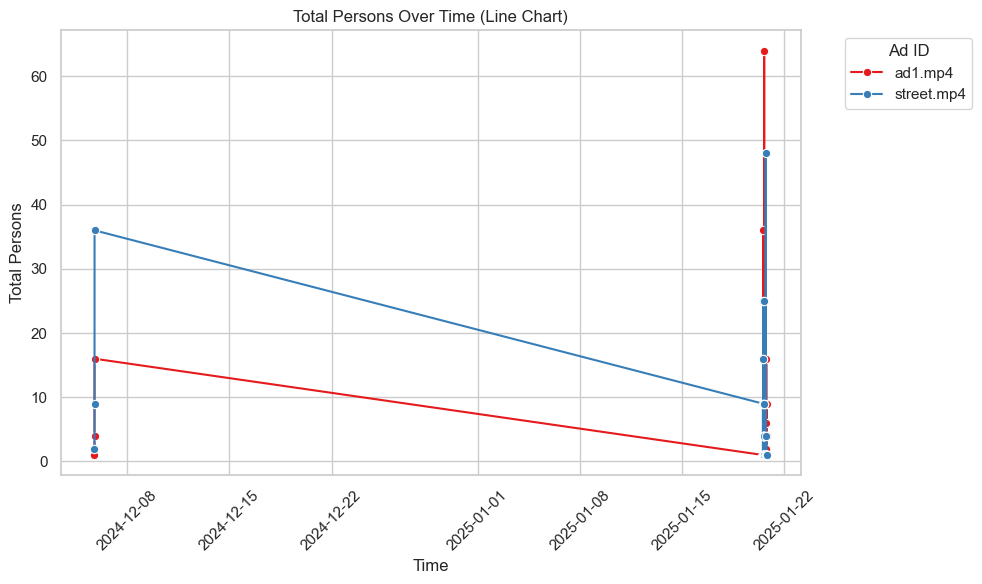

In [36]:
# Line chart showing total persons over time for each ad
line_chart_data = cleaned_data.groupby(['time', 'ad_id'])['total_persons'].sum().reset_index()
sns.lineplot(data=line_chart_data, x='time', y='total_persons', hue='ad_id', marker="o", palette='Set1')
plt.title("Total Persons Over Time (Line Chart)")
plt.xlabel("Time")
plt.ylabel("Total Persons")
plt.xticks(rotation=45)
plt.legend(title="Ad ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Bubble Chart: Age vs. Total Persons by Ad
This chart highlights the relationship between age and total persons, with bubble sizes representing the number of persons.

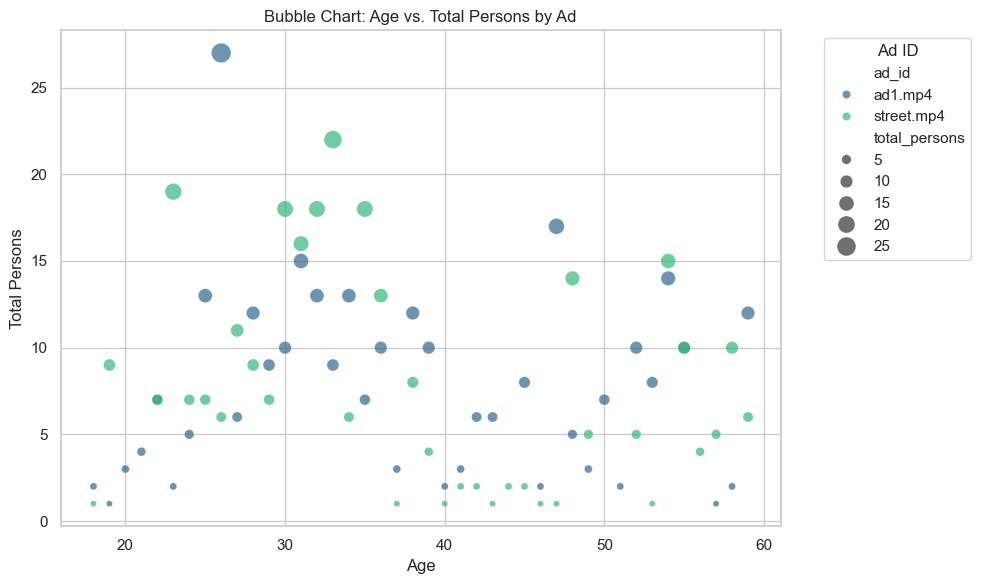

In [37]:
# Bubble chart
bubble_chart_data = cleaned_data.groupby(['ad_id', 'age'])['total_persons'].sum().reset_index()
sns.scatterplot(
    data=bubble_chart_data,
    x='age', y='total_persons', size='total_persons',
    hue='ad_id', palette='viridis', alpha=0.7, sizes=(20, 200)
)
plt.title("Bubble Chart: Age vs. Total Persons by Ad")
plt.xlabel("Age")
plt.ylabel("Total Persons")
plt.legend(title="Ad ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Box Plot: Age Distribution Across Ads
This chart helps compare the age distributions across different ads.

C:\Users\Asus\AppData\Local\Temp\ipykernel_4600\4067344442.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cleaned_data, x='ad_id', y='age', palette='Set3')


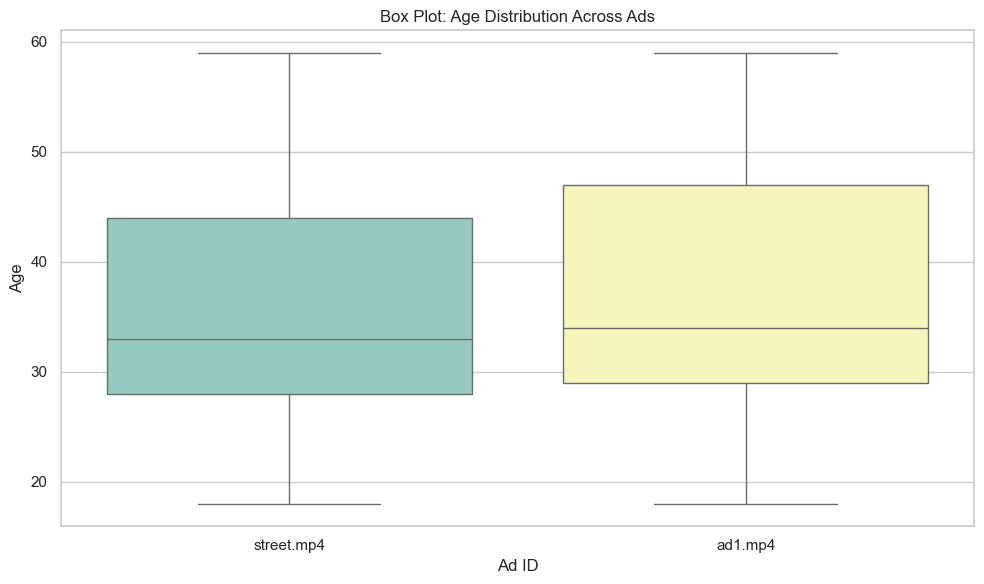

In [38]:
# Box plot for age distribution across ads
sns.boxplot(data=cleaned_data, x='ad_id', y='age', palette='Set3')
plt.title("Box Plot: Age Distribution Across Ads")
plt.xlabel("Ad ID")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

# Histogram: Age Distribution
This chart visualizes the frequency distribution of ages in the dataset.

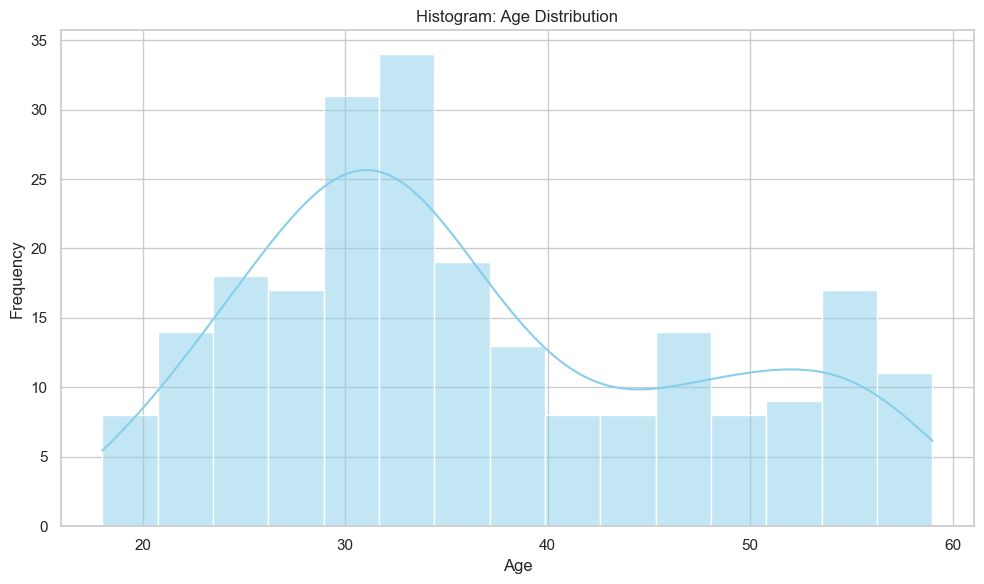

In [39]:
# Histogram for age distribution
sns.histplot(cleaned_data['age'], bins=15, kde=True, color='skyblue')
plt.title("Histogram: Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Scatter Plot: Age vs. Total Persons
This scatter plot shows the correlation between age and total persons

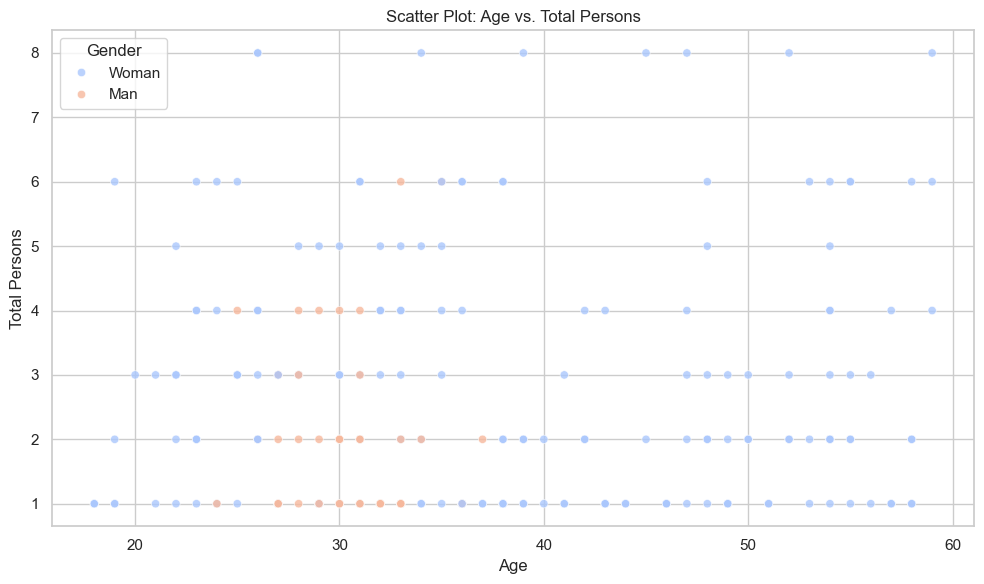

In [40]:
# Scatter plot for age vs. total persons
sns.scatterplot(data=cleaned_data, x='age', y='total_persons', hue='gender', palette='coolwarm', alpha=0.8)
plt.title("Scatter Plot: Age vs. Total Persons")
plt.xlabel("Age")
plt.ylabel("Total Persons")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

# Step 5: Statistical Analysis
1. Chi-Square Test for Gender Distribution

In [41]:
# Create a contingency table
gender_ad_ct = pd.crosstab(cleaned_data['ad_id'], cleaned_data['gender'])
chi2, p, dof, expected = chi2_contingency(gender_ad_ct)

print(f"Chi-Square Test Results:\nChi2: {chi2:.2f}, p-value: {p:.3f}, Degrees of Freedom: {dof}")

Chi-Square Test Results:
Chi2: 3.36, p-value: 0.067, Degrees of Freedom: 1


# Linear Regression Analysis

In [42]:
# Predict total persons using age
X = cleaned_data[['age']]
X = sm.add_constant(X)  # Add constant for intercept
y = cleaned_data['total_persons']

# Fit the model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          total_persons   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9673
Date:                Mon, 20 Jan 2025   Prob (F-statistic):              0.326
Time:                        19:43:27   Log-Likelihood:                -470.31
No. Observations:                 229   AIC:                             944.6
Df Residuals:                     227   BIC:                             951.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2293      0.438      5.092      0.0

# Save the Cleaned Data

In [43]:
# Save cleaned data to CSV
output_path = r"C:\Users\Asus\Music\CodeWithEhtisham\AddRover-pipeline\cleaned_data.csv"
cleaned_data.to_csv(output_path, index=False)

print(f"Cleaned data saved to {output_path}")

Cleaned data saved to C:\Users\Asus\Music\CodeWithEhtisham\AddRover-pipeline\cleaned_data.csv
